# Custom Autograd in PyTorch: ReLU to SiLU

This notebook builds intuition for implementing custom differentiable operations with `torch.autograd.Function`.

You will go through two connected parts:
1. **Part A: ReLU** - understand the core forward/backward pattern.
2. **Part B: SiLU with learnable slope** - extend the same pattern to a richer activation.

The main goals are to understand how gradients are derived, how tensors are saved in `ctx`, and how custom operations are validated with `gradcheck`.

## Why Custom Autograd?

PyTorch provides standard operations (linear, conv, activation), but sometimes you need:
- **Custom differentiable functions** with domain-specific gradients
- **Non-differentiable operations** with trainable gradients (Straight-Through Estimator)
- **Memory-efficient backward passes** by saving only what's needed
- **Specialized gradient computation** for research innovations

PyTorch's `torch.autograd.Function` lets you:
1. Define forward computation
2. Manually compute backward gradients
3. Control how information flows through your model

## Core Concepts Before Implementation

### The Design Pattern

```
class MyOp(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        # Compute output, save tensors needed for backward
        return output
    
    @staticmethod
    def backward(ctx, grad_output):
        # Retrieve saved tensors
        # Compute gradients w.r.t inputs
        return grad_input
```

### Key Components

| Component | Purpose | Notes |
|-----------|---------|-------|
| **@staticmethod** | No class instance created | PyTorch calls `MyOp.apply(x)`, not `MyOp().apply(x)` |
| **ctx object** | Bridge between forward & backward | Pass info forward → backward via `ctx` |
| **save_for_backward()** | Store tensors for backward | Only save what's needed (memory efficient) |
| **grad_output** | Gradient of loss w.r.t output | Received from backprop chain |
| **return grad_input** | Gradients for each input | Must have same number as forward args |


#### Note:
Also check https://docs.pytorch.org/tutorials/beginner/examples_autograd/polynomial_custom_function.html

In [140]:
import torch

class MyReLU(torch.autograd.Function):
    """
    Custom ReLU implementation using torch.autograd.Function.
    
    Forward: y = max(x, 0)
    Backward: dy/dx = 1 if x > 0 else 0
    """
    @staticmethod
    def forward(ctx, input):
        # Step 1: Save input for backward pass
        # We need input to know which neurons were "on" (> 0)
        ctx.save_for_backward(input)
        
        # Step 2: Compute forward pass
        # clamp(min=0) is equivalent to max(x, 0)
        return input.clamp(min=0)
    
    @staticmethod
    def backward(ctx, grad_output):
        # Step 1: Retrieve saved tensors
        input, = ctx.saved_tensors  # Note the comma: saved as tuple
        
        # Step 2: Clone instead of in-place modification
        # In-place ops break the computation graph
        grad_input = grad_output.clone()
        
        # Step 3: Apply ReLU mask
        # Where input <= 0, gradient is 0
        # Where input > 0, gradient passes through
        grad_input[input <= 0] = 0
        
        # Step 4: Return gradients (1 per input argument in forward)
        return grad_input

In [141]:
# Example 1: Forward pass
x = torch.tensor([-1.0, 2.0, 3.0], requires_grad=True)
y = MyReLU.apply(x)

print("Input x:", x)
print("Output y = MyReLU(x):", y)
print()

# Example 2: Backward pass (gradient computation)
print("Computing gradients...")
loss = y.sum()  # Simplified loss: sum of outputs
loss.backward()

print("Gradients (dy/dx):", x.grad)
print()
print("Explanation:")
print("  x[0] = -1.0 → ReLU output = 0.0 → gradient = 0 ❌ (neuron off)")
print("  x[1] = 2.0  → ReLU output = 2.0 → gradient = 1 ✓  (neuron on)")
print("  x[2] = 3.0  → ReLU output = 3.0 → gradient = 1 ✓  (neuron on)")

Input x: tensor([-1.,  2.,  3.], requires_grad=True)
Output y = MyReLU(x): tensor([0., 2., 3.], grad_fn=<MyReLUBackward>)

Computing gradients...
Gradients (dy/dx): tensor([0., 1., 1.])

Explanation:
  x[0] = -1.0 → ReLU output = 0.0 → gradient = 0 ❌ (neuron off)
  x[1] = 2.0  → ReLU output = 2.0 → gradient = 1 ✓  (neuron on)
  x[2] = 3.0  → ReLU output = 3.0 → gradient = 1 ✓  (neuron on)


In [142]:
# Let's verify our implementation is mathematically correct
# using PyTorch's numerical gradient checker

from torch.autograd import gradcheck

print("=" * 60)
print("VERIFICATION: Is our backward pass correct?")
print("=" * 60)

# For gradcheck, we need:
# 1. double precision (float64)
# 2. requires_grad=True
# 3. Avoid non-differentiable points (like exactly 0 for ReLU)

x_check = torch.randn(5, dtype=torch.double, requires_grad=True) + 0.1

try:
    # gradcheck compares numerical gradients vs analytical gradients
    result = gradcheck(MyReLU.apply, (x_check,), eps=1e-6, atol=1e-4)
    print(f"✓ Gradcheck passed: {result}")
except Exception as e:
    print(f"✗ Gradcheck failed: {e}")

VERIFICATION: Is our backward pass correct?
✓ Gradcheck passed: True


## Common Pitfalls & How to Avoid Them

| ❌ Problem | ✓ Solution | Why |
|-----------|-----------|-----|
| **In-place operations** `x[x<0]=0` | Clone first: `grad.clone()` then modify | In-place breaks backprop graph |
| **Wrong dtype** Using float32 | Use `torch.double` for `gradcheck` | Float32 doesn't have enough precision for numerical gradients |
| **Forgetting `save_for_backward`** | Save every tensor needed in backward | Backward won't have access to forward tensors |
| **Wrong return count** Returning only 1 gradient | Return gradient for each input arg | PyTorch expects tuple/list matching forward args |
| **Not cloning tensors** Direct assignment | Clone tensors with `.clone()` | Sharing tensors can cause backprop issues |
| **Non-differentiable points** ReLU exactly at 0 | Add small offset: `+ 0.1` | `gradcheck` can't verify at discontinuities |

# Part A Summary: ReLU Custom Autograd

Before moving to SiLU, this is the compact checklist from the ReLU section.

## Core Template

**`@staticmethod`**: PyTorch calls `MyOp.apply(...)` directly, so no class instance (`self`) is created.

**`ctx` (context object)**: Use it as the bridge from forward to backward.

**`save_for_backward(...)`**: Save only tensors required by backward to keep memory usage efficient.

**`backward(...)` return rule**: Return one gradient per forward input (use `None` for non-differentiable or non-tensor inputs).

This template is exactly what we reuse in the next section for a custom SiLU implementation.

# Part B: Custom SiLU Activation with Learnable Slope

We now extend the ReLU pattern to a smoother activation.

## Definition

We define a scaled SiLU:

$$
y = \operatorname{SiLU}_{\alpha}(x) = \alpha \cdot x \cdot \sigma(x), \qquad \sigma(x)=\frac{1}{1+e^{-x}}
$$

where:
- $x$ is the input tensor
- $\alpha$ (`slope`) is a learnable scalar parameter

When $\alpha=1$, this reduces to standard SiLU.

## Why add a learnable slope?

The parameter $\alpha$ controls activation magnitude. During training, the model can tune this scale to improve fit, instead of relying on a fixed activation amplitude.

## Gradients Used in Backward

For input:

$$
\frac{\partial y}{\partial x}=\alpha\left[\sigma(x)+x\sigma(x)(1-\sigma(x))\right]
$$

For slope:

$$
\frac{\partial y}{\partial \alpha}=x\sigma(x)
$$

During backpropagation, with `grad_output = \partial L/\partial y`:

$$
\frac{\partial L}{\partial x}=\frac{\partial L}{\partial y}\frac{\partial y}{\partial x},
\qquad
\frac{\partial L}{\partial \alpha}=\sum_i\frac{\partial L}{\partial y_i}\frac{\partial y_i}{\partial \alpha}
$$

The sum appears because `slope` is a single scalar shared across all tensor elements.

## What to look for in the next code cells

1. Forward saves exactly what backward needs.
2. Backward computes both `grad_input` and `grad_slope`.
3. `gradcheck` confirms the analytical gradients match numerical estimates.
4. A small model then uses this activation in training and visualization.

Reference inspiration:
https://github.com/Exorust/TorchLeet/blob/main/torch/hard/custom-autograd/custom-autgrad-function.ipynb

In [143]:
import torch

class MySiLU(torch.autograd.Function):
    """

    Args:
        torch (_type_): _description_
    """
    @staticmethod
    def forward(ctx, input, slope):
        ctx.save_for_backward(input, slope)
        sigmoid = torch.sigmoid(input) 
        return input * sigmoid * slope
    
    @staticmethod
    def backward(ctx, grad_output):
        input, slope = ctx.saved_tensors
        sigmoid = torch.sigmoid(input)
        grad_input = grad_output * (sigmoid + input * sigmoid * (1 - sigmoid)) * slope
        grad_slope = grad_output * input * sigmoid
        return grad_input, grad_slope
        

In [144]:
from torch.autograd import gradcheck

# Example usage (analytical gradients)
x = torch.tensor([-1.0, 2.0, 3.0], requires_grad=True)
slope = torch.tensor(0.5, requires_grad=True)

y = MySiLU.apply(x, slope)
print("Output y = MySiLU(x, slope):", y)

# Clear old grads in case this cell is rerun.
x.grad = None
slope.grad = None

loss = y.sum()
loss.backward()
print("Gradients (dL/dx):", x.grad)
print("Gradients (dL/dslope):", slope.grad)

# Numerical gradient check should use float64 and fresh leaf tensors.
x_check = torch.tensor([-1.0, 2.0, 3.0], dtype=torch.double, requires_grad=True)
slope_check = torch.tensor(0.5, dtype=torch.double, requires_grad=True)

result = gradcheck(MySiLU.apply, (x_check, slope_check), eps=1e-6, atol=1e-4)
print(f"Gradcheck passed: {result}")

Output y = MySiLU(x, slope): tensor([-0.1345,  0.8808,  1.4289], grad_fn=<MySiLUBackward>)
Gradients (dL/dx): tensor([0.0362, 0.5454, 0.5441])
Gradients (dL/dslope): tensor(4.3504)
Gradcheck passed: True


In [145]:
class LinearModel(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)

        # Learnable global slope for custom SiLU.
        self.slope = torch.nn.Parameter(torch.tensor(0.5))
        self.activation = MySiLU.apply

    def forward(self, x):
        # 1) linear projection, 2) custom activation with learnable slope
        return self.activation(self.linear(x), self.slope)

In [146]:
# Train a small model with custom SiLU
model = LinearModel(input_dim=2, output_dim=1)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

epochs = 1000

def target_function(x):
    # Nonlinear target surface in 2D.
    return 2 * x[:, 0] + 3 * x[:, 1] + 1

for epoch in range(epochs):
    # Sample a fresh batch each step.
    inputs = torch.randn(100, 2)
    targets = target_function(inputs).unsqueeze(1)

    # Forward pass.
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    # Backward + optimizer step.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print occasionally to keep output readable.
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}")

print(f"Learned slope: {model.slope.item():.4f}")

Epoch 1/1000, Loss: 14.1365
Epoch 100/1000, Loss: 4.7634
Epoch 200/1000, Loss: 4.6419
Epoch 300/1000, Loss: 2.2178
Epoch 400/1000, Loss: 2.0443
Epoch 500/1000, Loss: 1.6441
Epoch 600/1000, Loss: 3.4896
Epoch 700/1000, Loss: 3.5989
Epoch 800/1000, Loss: 1.3613
Epoch 900/1000, Loss: 2.9652
Epoch 1000/1000, Loss: 2.8063
Learned slope: 4.8566


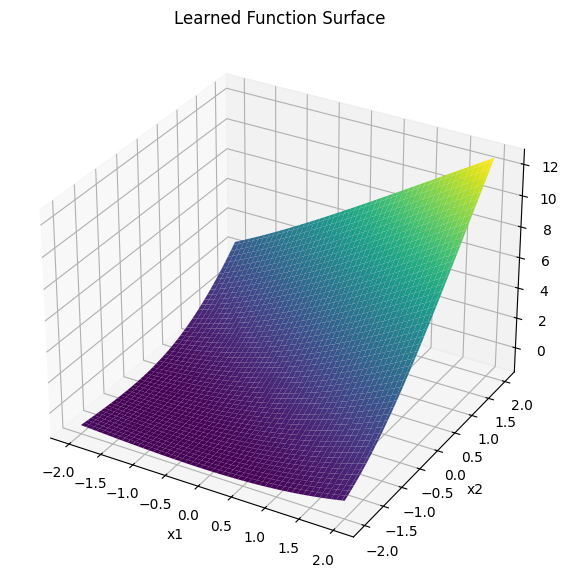

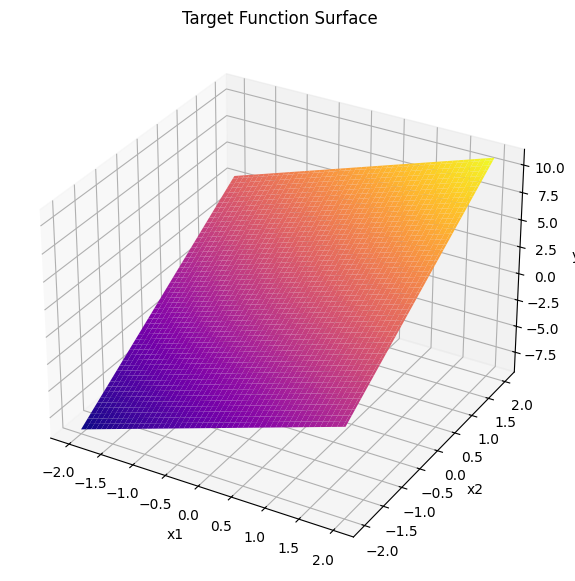

In [147]:
import matplotlib.pyplot as plt
import numpy as np

# Build a 2D grid.
x1 = np.linspace(-2, 2, 100)
x2 = np.linspace(-2, 2, 100)
X1, X2 = np.meshgrid(x1, x2)
grid = np.stack([X1.ravel(), X2.ravel()], axis=1)

with torch.no_grad():
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    # Predicted surface from the trained model.
    y_pred = model(grid_tensor).squeeze().cpu().numpy().reshape(X1.shape)

    # Ground-truth target surface.
    y_true = target_function(grid_tensor).cpu().numpy().reshape(X1.shape)

# Figure 1: Learned function
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection="3d")
ax1.plot_surface(X1, X2, y_pred, cmap="viridis", linewidth=0, antialiased=True)
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("y")
ax1.set_title("Learned Function Surface")
plt.show()

# Figure 2: Target function
fig2 = plt.figure(figsize=(10, 7))
ax2 = fig2.add_subplot(111, projection="3d")
ax2.plot_surface(X1, X2, y_true, cmap="plasma", linewidth=0, antialiased=True)
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("y")
ax2.set_title("Target Function Surface")
plt.show()